This notebook demonstrates the full optimization process for the first wedge and the dispersion suppressor.

Updated: 1/10/2026

# Setup

In [1]:

from scan import *
from g4beam import *
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
from scipy.optimize import differential_evolution
import re
import uuid

In [2]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


In [3]:
import scan, sys
print("scan imported from:", scan.__file__)
print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])

scan imported from: /home/incik/Cooling_4D/QQQDipole/scan.py
cwd: /home/incik/Cooling_4D/QQQDipole
sys.path[0]: /home/incik/miniconda3/lib/python312.zip


# Initial distribution

The parameters of the initial beam are treated as constants, but some things are known about their effects:
- **Transverse emittance**: Should be as low as possible. For this test we use an "optimistic" value of 110 microns.
- **Momentum**: Decreasing this appears to slightly decreases x-emittance.
- **Beta**: Decreasing this decreases the y-emittance growth. There may also be an optimal value for x-emittance.
- **Alpha**: Increasing this decreases the y-emittance growth, but past a certain point increases the x-emittance. I believe 0.7 focuses the beam onto the wedge center with a VD distance of 24 mm.
- **Longitudinal emittance**: Effects not yet tested.
- **Standard deviation of momentum**: Decreasing this decreases the x-emittance.
- **Virtual detector distance**: Almost irrelevant. Should be more than 3x the length of the wedge to ensure accurate measurements.

In [4]:
t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 0.7     # dimensionless
l_emit = 1      # mm
pz_std = 1    # MeV/c
vd_dist = 24    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
pre_w1["PDGid"] = -13
print_all_params(pre_w1)

-----------------------------
Twiss parameters for X
emit  = 0.14815605560919498 mm
beta  = 0.030117766006522766 m
gamma = 49.476541024150386 1/m
alpha = 0.7000877697671095
D     = -0.0002406653680779623 m
D'    = -0.022389286101389565

Twiss parameters for Y
emit  = 0.14513021648034494 mm
beta  = 0.029855025289382945 m
gamma = 49.56398028496772 1/m
alpha = 0.6926282443347143
D     = 0.0009156753909011476 m
D'    = -0.038689573390966146

Z-emittance:  1.272506003362205 mm
Z std: 153.84858583548282 mm
p std: 1.0071185911325828 MeV/c
Mean momentum: 100.00527832124166 MeV/c
-----------------------------


In [5]:
write_trackfile(pre_w1, "particles_before.txt")

# First wedge

Determines the optimal length and angle for the first wedge

In [6]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

start = time.time()
# Run optimization
optim_result = minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w1_length, w1_angle = optim_result.x
print(f"Length = {w1_length:.2f} mm\nAngle = {w1_angle:.1f} deg")
print("Time spent:", time.time()-start)

# Runs a single case with the optimal parameters
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
print_all_params(post_w1)
print_all_params(cut_outliers(post_w1))

iter value
  42 4.25590e-02
Length = 6.96 mm
Angle = 46.3 deg
Time spent: 1348.2846093177795
-----------------------------
Twiss parameters for X
emit  = 0.04751131994554819 mm
beta  = 0.03507601845174594 m
gamma = 184.9514048766147 1/m
alpha = -2.3425112358596003
D     = 0.020857745193773928 m
D'    = -0.0546774919496505

Twiss parameters for Y
emit  = 0.15079355617017914 mm
beta  = 0.02552915216337836 m
gamma = 57.59210790562077 1/m
alpha = -0.6857679535617703
D     = -2.640984742412392e-05 m
D'    = 0.0037125752304698117

Z-emittance:  6.260314930014158 mm
Z std: 143.09496110329164 mm
p std: 7.01963215298433 MeV/c
Mean momentum: 88.19057833290202 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.042558965502960996 mm
beta  = 0.03627332616858844 m
gamma = 199.82047005223671 1/m
alpha = -2.499630589780306
D     = 0.020916460098481148 m
D'    = -0.06694986667478929

Twiss parameters for Y
emit  = 0.1485831129155009 mm
beta  = 0.025546559

In [7]:
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
print_all_params(post_w1)
print_all_params(cut_outliers(post_w1))

-----------------------------
Twiss parameters for X
emit  = 0.04751131994554819 mm
beta  = 0.03507601845174594 m
gamma = 184.9514048766147 1/m
alpha = -2.3425112358596003
D     = 0.020857745193773928 m
D'    = -0.0546774919496505

Twiss parameters for Y
emit  = 0.15079355617017914 mm
beta  = 0.02552915216337836 m
gamma = 57.59210790562077 1/m
alpha = -0.6857679535617703
D     = -2.640984742412392e-05 m
D'    = 0.0037125752304698117

Z-emittance:  6.260314930014158 mm
Z std: 143.09496110329164 mm
p std: 7.01963215298433 MeV/c
Mean momentum: 88.19057833290202 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.042558965502960996 mm
beta  = 0.03627332616858844 m
gamma = 199.82047005223671 1/m
alpha = -2.499630589780306
D     = 0.020916460098481148 m
D'    = -0.06694986667478929

Twiss parameters for Y
emit  = 0.1485831129155009 mm
beta  = 0.025546559106406953 m
gamma = 56.97135718451129 1/m
alpha = -0.6748497193348606
D     = 8.0082359472649

In [8]:
# Optimized G4_FinalCooling_auto.g4bl parameters
offset = w1_length / (math.tan(w1_angle * math.pi / 180) * 2)
base_length = 2*offset
abswidth = 100
parameters = dict(
        abshalfangle3=str(w1_angle),
        absoffset3=str(offset),
        abshgt=str(offset * base_length / w1_length + 0.1),
        absLEN3=str(base_length)
    )
L_centerline = float(parameters['absLEN3']) + 1
print("Where to put the next element: " + str(L_centerline) + "mm")

Where to put the next element: 7.6568483715846565mm


In [9]:
# Write the wedge output into a file
write_trackfile(post_w1, "particles_afterbqqq.txt")

In [10]:
# If particles_after isn't updated with Z = 0.
def convertZ(input_file, output_file, set_to=0):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = str(set_to)  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None

In [11]:
convertZ("particles_afterbqqq.txt", "particles_afterbqqqupt.txt", set_to=0.0)

Updated file saved as 'particles_afterbqqqupt.txt'


Text(0, 0.5, 'Px (MeV/c)')

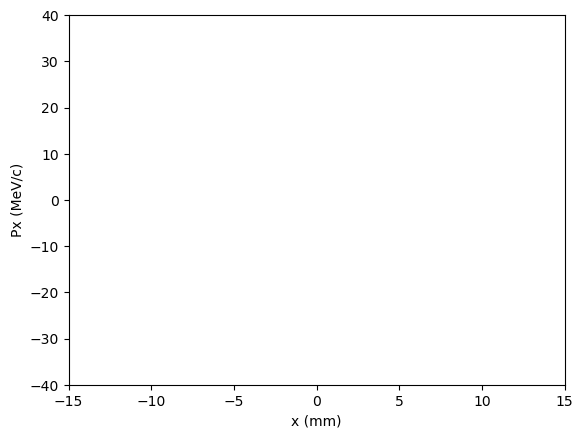

In [12]:
x_params, y_params, _ = calc_all_params(post_w1)
plt.scatter(post_w1["x"], post_w1["Pz"], s=0.1, color="purple")
plt.xlim(-15, 15)
plt.ylim(-40, 40)
plt.xlabel("x (mm)")
plt.ylabel("Px (MeV/c)")

In [13]:
# Initial Values Post-Wedge
x0_params, y0_params, _ = calc_all_params(post_w1)
beta_x_ref= x0_params[1]; beta_y_ref= y0_params[1]
print(r"$\beta_x$: " + str(beta_x_ref), r"$\beta_y$: " + str(beta_y_ref))
print("D_x: " + str(x0_params[4]), "D_y: " + str(y0_params[4]))

$\beta_x$: 0.03507601845174594 $\beta_y$: 0.02552915216337836
D_x: 0.020857745193773928 D_y: -2.640984742412392e-05


In [14]:
def beam_size(beta, eps, n_sigma=15):
    """
    Compute full beam width/height in mm for given beta (m) and emittance (mm·mrad)
    """
    sigma = np.sqrt(beta * eps * 1e3)  # convert sigma (mm) = sqrt(m * 1e3 * mm)
    return n_sigma * sigma

n_sigma_x = beam_size(x_params[1], x_params[0])
n_sigma_y = beam_size(y_params[1], y_params[0])
print("Determine the Dipole Width: " + str(n_sigma_x),"Determine the Dipole Height: " + str(n_sigma_y))

Determine the Dipole Width: 19.363994561874158 Determine the Dipole Height: 29.430717272319836


'radius_q = max(n_sigma_x, n_sigma_y)\nprint("So the quad radius: " + str(radius_q) + " mm")'

# Dispersion correction optimization

The main goal is to have $D_x \approx 0$ up to 1e-5 m while keeping $\beta_x$ relatively periodic and about at the same value.

In [15]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, replacements, out_path):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [16]:
def clean_field_files():
    for f in ["field_cellQ1.dat", "field_cellQ2.dat"]:
        if os.path.exists(f):
            os.remove(f)


In [33]:
def check_dipole_clearance(df, B_val, B_radius, B_angle, B_thickness):
    """
    Check which particles clear the dipole aperture based on their Larmor radius
    and deflection geometry.

    Parameters:
      df : pandas.DataFrame with columns ['Px','Py','Pz'] in MeV/c
      B_val : magnetic field (Tesla)
      dipole_length_mm : dipole magnet effective length (mm)
      dipole_halfwidth_mm : half-width of dipole aperture (mm)

    Returns:
      surviving_mask : boolean array, True if particle clears aperture
      r_L_mm : array of Larmor radii (mm)
      delta_r_mm : array of deflections (mm)
    """
    dipole_length_mm = 2 * B_radius * math.sin(B_angle * math.pi/360)
    dipole_halfwidth_mm = B_thickness
    # constants
    e = 1.602176634e-19  # C
    c = 2.99792458e8     # m/s

    # convert MeV/c to SI (kg·m/s)
    mom_perp = np.sqrt(df["Px"]**2 + df["Pz"]**2) * 1e6 * e / c  # B assumed along y

    # Larmor radius [m]
    r_L = mom_perp / (e * np.abs(B_val))

    # convert to mm
    r_L_mm = r_L * 1e3
    s_mm = dipole_length_mm

    # deflection Δr = r * (1 - cos(φ)), φ = s / r
    phi = s_mm / r_L_mm
    delta_r_mm = r_L_mm * (1 - np.cos(phi))

    # check if deflection < half-width
    surviving_mask = delta_r_mm < dipole_halfwidth_mm
    

    return surviving_mask, r_L_mm, delta_r_mm
def run_dipole(df, B_field, B_angle, B_radius, B_z, B_thickness=n_sigma_x, B_height=n_sigma_y):
    if os.path.exists("field_cellBSec.dat"):
        os.remove("field_cellBSec.dat")
    """Run dipole simulation with given parameters."""
    params = {
        "B1_field": B_field,
        "B1_angle": B_angle,
        "B1_radius": B_radius,
        "B1_z": B_z,
        "B1_z_end": B_z + 2 * (B_radius * B_angle * math.pi/360)+0.1,
        "B1_x_end": B_z - B_thickness * math.sin(B_angle * math.pi/360),
        "B1_thickness": B_thickness,
        "B1_height": B_height,
    }
    
    write_input_from_template("G4_FinalCooling_dispsup_BSec.g4bl", params, "G4_FinalCooling_dispsup_BSec_run.g4bl")
    # Run G4Beamline
    df_out = run_g4beam(df, "G4_FinalCooling_dispsup_BSec_run.g4bl")

    return df_out
def optimize_dipole(x, df_in, beta_x_ref, beta_y_ref, 
                    w_disp=1000.0, w_beta=10.0, w_clear=100.0, 
                    D_tol=1e-4, survival_threshold=0.95):
    """
    Optimize dipole parameters using G4Beamline simulations.

    Parameters
    ----------
    x : array-like
        Dipole parameters: [B_field, B_angle_deg, B_radius]
    df_in : pandas.DataFrame
        Input particle distribution
    beta_x_ref, beta_y_ref : float
        Target beta functions
    w_disp, w_beta : float
        Weights for cost function
    survival_threshold : float
        Minimum fraction of particles that must survive

    Returns
    -------
    float
        Objective function value (smaller is better)
    """
    # Unpack parameters
    B_field, B_angle, B_radius, B_z = x
    B_thickness = n_sigma_x
    B_height = n_sigma_y

    # Run dipole simulation
    result = run_dipole(df_in, B_field, B_angle, B_radius, B_z)
    if result is None or len(result) == 0:
        # no particles survived, penalize heavily
        return 1e6

    mask, r_L_mm, delta_r_mm = check_dipole_clearance(df_in, B_field, B_angle, B_radius, B_thickness)
    mask = mask[:len(result)]  # truncate if needed
    if len(result) == 0:
        survival_frac = 0.0
    else:
        if isinstance(result, np.ndarray):
            df_survived = result[mask]
        else:
            df_survived = result[mask.values]
        survival_frac = len(df_survived) / 2000 # len(df_in)

    if survival_frac < survival_threshold:
        return 1e6 + 1e3*(survival_threshold - survival_frac)


    # Compute dispersion & beta from survived particles
    df_survived = result[mask] if isinstance(result, np.ndarray) else result[mask.values]
    x_params_d, y_params_d, _ = calc_all_params(df_survived)
    Dx, beta_x = x_params_d[4], x_params_d[1]
    Dy, beta_y = y_params_d[4], y_params_d[1]

    # Penalties
    disp_penalty = ((Dx - 0)/D_tol)**2  # target dispersion = 0 at end
    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    # Total objective function
    val = w_disp * disp_penalty # + w_beta * beta_penalty

    print(f"Objective = {val:.3f}, Survival = {survival_frac:.3f}, Dx = {Dx:.3f}, beta_x = {beta_x:.3f}, beta_y = {beta_y:.3f}")
    return val

In [34]:
start = time.time()
# Run optimization
optim_result = minimize(optimize_dipole, [-0.5, 2.0, 1000.0, 10.0], args=(post_w1, beta_x_ref, beta_y_ref), method="Nelder-Mead", bounds=((-3.0, 3.0), (1.0, 10.0), (100.0, 2000.0), (1.0, 3000.0)), options=dict(fatol=1e-6))

# Get results
B_field, B_angle, B_radius, B_z = optim_result.x
print(f"Field = {B_field:.2f} T \nAngle = {B_angle:.2f} deg\nRadius = {B_radius:.1f} mm\nSpacing= {B_z:.1f} mm")
print("Time spent:", time.time()-start)

iter value
Objective = 24709743.738, Survival = 0.975, Dx = 0.016, beta_x = 0.643, beta_y = 0.199
Objective = 24513961.507, Survival = 0.975, Dx = 0.016, beta_x = 0.645, beta_y = 0.199
Objective = 25430611.728, Survival = 0.972, Dx = 0.016, beta_x = 0.680, beta_y = 0.209
Objective = 25422054.910, Survival = 0.972, Dx = 0.016, beta_x = 0.680, beta_y = 0.209
Objective = 24968261.499, Survival = 0.974, Dx = 0.016, beta_x = 0.654, beta_y = 0.201
Objective = 24620997.496, Survival = 0.976, Dx = 0.016, beta_x = 0.631, beta_y = 0.195
Objective = 26236639.955, Survival = 0.978, Dx = 0.016, beta_x = 0.607, beta_y = 0.189
Objective = 24673884.896, Survival = 0.974, Dx = 0.016, beta_x = 0.662, beta_y = 0.204
Objective = 24312047.626, Survival = 0.975, Dx = 0.016, beta_x = 0.636, beta_y = 0.196
Objective = 24290627.405, Survival = 0.976, Dx = 0.016, beta_x = 0.627, beta_y = 0.194
Objective = 24199551.433, Survival = 0.975, Dx = 0.016, beta_x = 0.638, beta_y = 0.197
Objective = 25386375.656, Surviv

np.float64(-1.0798334948647084)

In [36]:
# Run a single case of optimal values
opt_params = {
        "B1_field": optim_result.x[0],
        "B1_angle": optim_result.x[1],
        "B1_radius": optim_result.x[2],
        "B1_z": optim_result.x[3],
        "B1_z_end": optim_result.x[3] + 2 * (optim_result.x[2] * optim_result.x[1] * math.pi/360)+0.1,
        "B1_x_end": optim_result.x[3] - n_sigma_x * math.sin(optim_result.x[1] * math.pi/360),
        "B1_thickness": n_sigma_x,
        "B1_height": n_sigma_y,
    }
if os.path.exists("field_cellBSec.dat"):
    os.remove("field_cellBSec.dat")
write_input_from_template("G4_FinalCooling_dispsup_BSec.g4bl", opt_params, "G4_FinalCooling_dispsup_BSec_opt.g4bl")
result = subprocess.run(["g4bl", "G4_FinalCooling_dispsup_BSec_opt.g4bl"], capture_output=True, text=True, check=True)
df_dip = read_trackfile("particles_after_bsec.txt")
x_params_dip, y_params_dip, z_emit_dip = calc_all_params(df_dip)
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)

{'B1_field': np.float64(-1.0798334948647084), 'B1_angle': np.float64(2.112929930701326), 'B1_radius': np.float64(1379.4444000127064), 'B1_z': np.float64(1.0), 'B1_z_end': np.float64(51.970576948162034), 'B1_x_end': np.float64(0.6429715622495084), 'B1_thickness': np.float64(19.363994561874158), 'B1_height': np.float64(29.430717272319836)}
{'D_x': np.float64(0.011344593149004876), "D'_x": np.float64(-0.2628016756042091), 'D_y': np.float64(-0.0001692814474444511), "D'_y": np.float64(-0.003555973338971033)} Epsilon_z: 6.568308686789306 {'Beta_x': np.float64(0.9378504686324582), 'Beta_y': np.float64(0.2251451674806825)}


In [ ]:
n_sigma_x_d = beam_size(x_params_dip[1], x_params_dip[0])
n_sigma_y_d = beam_size(y_params_dip[1], y_params_dip[0])
print("Determine the Dipole Width: " + str(n_sigma_x_d),"Determine the Dipole Height: " + str(n_sigma_y_d))
radius_q = max(n_sigma_x_d, n_sigma_y_d)
print("So the quad radius: " + str(radius_q) + " mm")
B_pole_max = 2.0
gradBound = B_pole_max / (radius_q*1e-3)
print(f"Max gradient bound for quads : ({-gradBound}, {gradBound})")

In [30]:
def run_three_quadrupoles(df, Q1_gradient, Q2_gradient, Q3_gradient, Drift1_length, Drift2_length, Q1_length=100, Q2_length=100, Q3_length=100, Q1_radius=radius_q, Q2_radius=radius_q, Q3_radius=radius_q, Q1_z=L_centerline, thickness=5):
    """
    Runs G4BL with two sequential quadrupoles.
    """
    Drift1_width=2*max(Q1_radius,Q2_radius)
    Drift1_height=2*max(Q1_radius,Q2_radius)
    Drift2_width=2*max(Q1_radius,Q2_radius)
    Drift2_height=2*max(Q1_radius,Q2_radius)
    # Q1_z : f"{L_centerline + (Q1_length / 2):.12f}",
    params = {
    "Q1_z": f"{Q1_z + (Q1_length / 2):.12f}",
    "Q1_length": f"{Q1_length:.12f}",
    "Q1_gradient": f"{Q1_gradient:.12f}",
    "radius_q1": f"{Q1_radius:.12f}",
    "radius_q2": f"{Q2_radius:.12f}",
    "radius_q3": f"{Q3_radius:.12f}",
    "thickness": f"{thickness:.12f}",
    "Q1_end": f"{Q1_z + Q1_length:.12f}",
    "Q2_length":f"{Q2_length:.12f}",
    "Q2_gradient": f"{Q2_gradient:.12f}",
    "Q3_length":f"{Q3_length:.12f}",
    "Q3_gradient": f"{Q3_gradient:.12f}",
    "Drift1_length": f"{Drift1_length:.12f}",
    "Drift1_z": f"{Q1_z + Q1_length + (Drift1_length / 2):.12f}",
    "Drift1_width": f"{Drift1_width:.12f}", 
    "Drift1_height":f"{Drift1_height:.12f}", 
    "Drift2_length": f"{Drift2_length:.12f}",
    "Drift2_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length + (Drift2_length/2):.12f}",
    "Drift2_width": f"{Drift2_width:.12f}", 
    "Drift2_height":f"{Drift2_height:.12f}", 
    "D1_end": f"{Q1_z + Q1_length + Drift1_length:.12f}",
    "D2_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length + Drift2_length:.12f}",
    "Q2_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length/2:.12f}",
    "Q3_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length + Drift2_length+(Q3_length/2):.12f}",
    "Q2_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length:.12f}",
    "Q3_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length + Drift2_length+Q3_length:.12f}"
    }

    print("PARAMS PASSED TO TEMPLATE:")
    for k, v in params.items():
        print(k, "=", v)
    write_input_from_template("G4_FinalCooling_dispsup_Q3.g4bl", params, "G4_FinalCooling_dispsup_Q3_run.g4bl")
    
    # Run this file
    clean_field_files()
    res = run_g4beam(df, "G4_FinalCooling_dispsup_Q3_run.g4bl")

    if res is None or len(res) < 10:
        print("G4BL run failed or empty. Check template and parameters.")
        return None
    return res

In [31]:
history = []
def optimize_qqq_drift_safe(x, df, beta_x_ref, beta_y_ref,
                           w_disp=1.0, w_beta=10.0, w_surv=100.0):
    """
    Optimizer wrapper with:
    - Survival-aware penalty
    - Full diagnostics
    """

    q1_gradient, q2_gradient, q3_gradient, d1_length, d2_length = x
    print("\nTRYING x =", x)

    try:
        result = run_three_quadrupoles(df, q1_gradient, q2_gradient, q3_gradient, d1_length, d2_length)
    except Exception as e:
        print("EXCEPTION in run_three_quadrupoles:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # Compute survival fraction
    N0 = len(df)
    Ns = len(result)
    survival = Ns / N0
    survival_penalty = w_surv * (1.0 - survival)**2
    print(f"Particles survived: {Ns}/{N0} → penalty {survival_penalty:.3f}")

    # Compute optics parameters
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5

    Dx = x_params[4]
    Dy = y_params[4]
    beta_x = x_params[1]
    beta_y = y_params[1]

    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2
    eps = 1e-4

    # Log-scaled optics loss
    optics_loss = np.log(Dx**2 + eps) + np.log(beta_penalty**2 + eps)

    # Total objective
    val = optics_loss + survival_penalty

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, beta_penalty={beta_penalty:.6f}")
    history.append({
    "Q1_G": q1_gradient,
    "Q2_G": q2_gradient,
    "Q3_G": q3_gradient,
    "Drift1_L": d1_length,
    "Drift2_L": d1_length,
    "Dx": Dx,
    "beta_x": beta_x,
    "beta_y": beta_y,
    "survival": survival,
    "objective": val})

    return val


In [166]:
x0 = [ -9.00758863, 11.56562394,-64.33913586,419.697143,  27.06839748]
# Physical bounds
bounds = np.array([
    [-gradBound, gradBound],      # Q1_gradient
    [-gradBound, gradBound],    # Q2_gradient
    [-gradBound, gradBound],      # Q3_gradient
    [20, 1000],    # Drift1_length
    [20, 1000]    # Drift2_length
])
res = scipy.optimize.minimize(
    optimize_qqq_drift_safe, x0,
    args=(df_dip, b_dict_dip[0], b_dict_dip[1]),
    method="Nelder-Mead", bounds=bounds,
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)
print("Optimal parameters:", res.x)


TRYING x = [ -9.00758863  11.56562394 -64.33913586 419.697143    27.06839748]
PARAMS PASSED TO TEMPLATE:
Q1_z = 57.995806656099
Q1_length = 100.000000000000
Q1_gradient = -9.007588630000
radius_q1 = 29.255644543054
radius_q2 = 29.255644543054
radius_q3 = 29.255644543054
thickness = 5.000000000000
Q1_end = 107.995806656099
Q2_length = 100.000000000000
Q2_gradient = 11.565623940000
Q3_length = 100.000000000000
Q3_gradient = -64.339135860000
Drift1_length = 419.697143000000
Drift1_z = 317.844378156099
Drift1_width = 58.511289086108
Drift1_height = 58.511289086108
Drift2_length = 27.068397480000
Drift2_z = 641.227148396099
Drift2_width = 58.511289086108
Drift2_height = 58.511289086108
D1_end = 527.692949656099
D2_end = 654.761347136100
Q2_z = 577.692949656099
Q3_z = 704.761347136100
Q2_end = 627.692949656099
Q3_end = 754.761347136100
Particles survived: 809/12000 → penalty 86.971
OBJECTIVE = 84.917043, Dx=0.014392, beta_penalty=20.431569

TRYING x = [ -9.45796806  11.56562394 -64.33913586

In [32]:
# [165.44850696   1.         117.80564137 -16.64715284  10. 20.        ]
# [203.10586964   1.         242.37880814  -7.24549651  10. 20.        ]
#print(res.x)
res_act = [ -3.92294325,  23.70551369, -53.13069084,  41.00619067,  30.16191789]# [ -9.00758863, 11.56562394,-64.33913586,419.697143,  27.06839748]

In [33]:
if os.path.exists("field_cellQ3.dat"):
    os.remove("field_cellQ3.dat")
df_opt = run_three_quadrupoles(post_w1, Q1_gradient=res_act[0], Q2_gradient=res_act[1],
                             Q3_gradient=res_act[2], Drift1_length=res_act[3],
                             Drift2_length=res_act[4])
print(df_opt)
write_trackfile(df_opt, "particles_after_q3.txt")

PARAMS PASSED TO TEMPLATE:
Q1_z = 57.543072498437
Q1_length = 100.000000000000
Q1_gradient = -3.922943250000
radius_q1 = 29.448658444995
radius_q2 = 29.448658444995
radius_q3 = 29.448658444995
thickness = 5.000000000000
Q1_end = 107.543072498437
Q2_length = 100.000000000000
Q2_gradient = 23.705513690000
Q3_length = 100.000000000000
Q3_gradient = -53.130690840000
Drift1_length = 41.006190670000
Drift1_z = 128.046167833437
Drift1_width = 58.897316889991
Drift1_height = 58.897316889991
Drift2_length = 30.161917890000
Drift2_z = 263.630222113437
Drift2_width = 58.897316889991
Drift2_height = 58.897316889991
D1_end = 148.549263168437
D2_end = 278.711181058437
Q2_z = 198.549263168437
Q3_z = 328.711181058437
Q2_end = 248.549263168437
Q3_end = 378.711181058437
             x         y        z        Px        Py       Pz        t  \
0    -13.31350   5.52161  378.711 -13.17530  -6.74142  89.7965  3.25615   
1     25.34080  12.96950  378.711  22.84050 -22.80930  67.3245  1.90586   
2      8.597

In [34]:
x_params, y_params, z_emit = calc_all_params(df_opt)
print("Dx, Dy =", x_params[4], y_params[4])

Dx, Dy = -0.001150924280913016 0.0027919670416279947


In [35]:
b_dict = {"Beta_x" : x_params[1], "Beta_y" : y_params[1]}
print(b_dict)

{'Beta_x': np.float64(0.24687398114456036), 'Beta_y': np.float64(0.10457392516750452)}


In [40]:
if os.path.exists("particles_after_q3upt.txt"):
    os.remove("particles_after_q3upt.txt")
convertZ("particles_after_q3.txt", "particles_after_q3upt.txt", set_to=0.0)

Updated file saved as 'particles_after_q3upt.txt'


In [1]:
with open("particles_after_q3upt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 12000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

3618
30.15


In [42]:
def check_dipole_clearance(df, B_val, dipole_length_mm, dipole_halfwidth_mm):
    """
    Check which particles clear the dipole aperture based on their Larmor radius
    and deflection geometry.

    Parameters:
      df : pandas.DataFrame with columns ['Px','Py','Pz'] in MeV/c
      B_val : magnetic field (Tesla)
      dipole_length_mm : dipole magnet effective length (mm)
      dipole_halfwidth_mm : half-width of dipole aperture (mm)

    Returns:
      surviving_mask : boolean array, True if particle clears aperture
      r_L_mm : array of Larmor radii (mm)
      delta_r_mm : array of deflections (mm)
    """

    # constants
    e = 1.602176634e-19  # C
    c = 2.99792458e8     # m/s

    # convert MeV/c to SI (kg·m/s)
    mom_perp = np.sqrt(df["Px"]**2 + df["Pz"]**2) * 1e6 * e / c  # B assumed along y

    # Larmor radius [m]
    r_L = mom_perp / (e * np.abs(B_val))

    # convert to mm
    r_L_mm = r_L * 1e3
    s_mm = dipole_length_mm

    # deflection Δr = r * (1 - cos(φ)), φ = s / r
    phi = s_mm / r_L_mm
    delta_r_mm = r_L_mm * (1 - np.cos(phi))

    # check if deflection < half-width
    surviving_mask = delta_r_mm < dipole_halfwidth_mm


    return surviving_mask, r_L_mm, delta_r_mm

In [43]:
def run_dipole(df, B_field, B_length, Drift3_length, Drift2_z=0):
    """Run dipole simulation with given parameters."""
    B_width=2*radius_q
    B_height=2*radius_q
    params = {
        "Drift3_length": Drift3_length, 
        "Drift3_width": B_width,
        "Drift3_height": B_height,
        "Drift3_z": Drift2_z + Drift3_length/2,
        "D3_end": Drift2_z + Drift3_length,
        "B1_field": B_field,
        "B1_z": Drift2_z + Drift3_length + B_length/2,
        "B1_end": Drift2_z + Drift3_length + B_length,
        "B1_length": B_length,
        "B1_width": B_width,
        "B1_height": B_height
    }
    write_input_from_template("G4_FinalCooling_dispsup_BSec.g4bl", params, "G4_FinalCooling_dispsup_BSec_run.g4bl")
    outfile = "G4_FinalCooling_dispsup_BSec_run.g4bl"
    return run_g4beam(df, "G4_FinalCooling_dispsup_BSec_run.g4bl")

In [44]:
history_d =[]
def optimize_dipole_safe(x, df, beta_x_ref, beta_y_ref,
                         w_disp=1000.0, w_beta=10.0, w_surv=100.0):
    """
    Dipole optimizer with smooth survival penalty
    x = [B_field, B_length, Drift2_length]
    """

    B_field, B_length, Drift2_length = x
    print("\nTRYING dipole x =", x)

    try:
        result = run_dipole(df, B_field, B_length, Drift2_length)
    except Exception as e:
        print("EXCEPTION in run_dipole:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # --- Survival (ground truth from G4BL)
    N0 = len(df)
    Ns = len(result)
    survival = Ns / N0
    survival_penalty = w_surv * (1.0 - survival)**2

    print(f"Survival: {Ns}/{N0} → penalty {survival_penalty:.3f}")

    # --- Optics
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5

    Dx = x_params[4]
    beta_x = x_params[1]
    beta_y = y_params[1]

    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 \
                 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    eps = 1e-6
    optics_loss = 100* np.log(Dx**2 + eps) + 10* np.log(beta_penalty**2 + eps)

    val = optics_loss + survival_penalty

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, beta_penalty={beta_penalty:.6f}")
    history_d.append({
        "B_F": B_field,
        "B_L": B_length,
        "D2_L": Drift2_length,
        "Dx": Dx,
        "beta_x": beta_x,
        "beta_y": beta_y,
        "survival": survival,
        "objective": val})
    return val


In [51]:
# initial guess: B_field (T), B_length (mm), Drift2_length (mm)
x0_dip = [0.15, 200.0, 100.0]

# bounds
bounds_dip = [(-3.0, 3.0),  # B_field
              (50, 400),   # B_length
              (20, 1000)]  # Drift2_length

res_dip = minimize(optimize_dipole_safe, x0_dip, args=(df_opt, b_dict['Beta_x'], b_dict['Beta_y']),
                method="Nelder-Mead", bounds=bounds_dip)

print("Optimal dipole parameters:", res_dip.x)

iter value

TRYING dipole x = [1.5e-01 2.0e+02 1.0e+02]
Survival: 1695/3618 → penalty 28.250
OBJECTIVE = -585.736547, Dx=-0.029197, beta_penalty=102.687872

TRYING dipole x = [1.575e-01 2.000e+02 1.000e+02]
Survival: 1692/3618 → penalty 28.338
OBJECTIVE = -581.210041, Dx=-0.029936, beta_penalty=99.876431

TRYING dipole x = [1.5e-01 2.1e+02 1.0e+02]
Survival: 1662/3618 → penalty 29.228
OBJECTIVE = -652.962795, Dx=-0.020541, beta_penalty=113.539773

TRYING dipole x = [1.50e-01 2.00e+02 1.05e+02]
Survival: 1735/3618 → penalty 27.087
OBJECTIVE = -585.186041, Dx=-0.029221, beta_penalty=110.970618

TRYING dipole x = [1.42500000e-01 2.06666667e+02 1.03333333e+02]
Survival: 1697/3618 → penalty 28.191
OBJECTIVE = -660.659635, Dx=-0.019765, beta_penalty=119.487208

TRYING dipole x = [1.35e-01 2.10e+02 1.05e+02]
Survival: 1707/3618 → penalty 27.899
OBJECTIVE = -623.925211, Dx=-0.023585, beta_penalty=130.458927
   1 -6.60660e+02
TRYING dipole x = [1.45000000e-01 2.11111111e+02 9.72222222e+01]
Surv

In [ ]:
# res_act = [1.38686570e-01 2.31251997e+02 1.01051327e+02]
df_opt_d = run_dipole(df_opt, B_field=res_dip.x[0], B_length=res_dip.x[1], Drift3_length=res_dip.x[2])
x_params_d, y_params_d, z_emit_d = calc_all_params(df_opt_d)
print("Dx Dy: ", x_params_d[4], y_params_d[4])
print("Betax Betay: ", x_params_d[1], y_params_d[1])

# best params:[1.38686570e-01 2.31251997e+02 1.01051327e+02]
write_trackfile(df_opt_d, "particles_after_b.txt")

Dx Dy:  -6.85933641790288e-05 -0.0056269374919919665
Betax Betay:  2.381843395463605 0.9820812158433793


In [53]:
with open("particles_after_b.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = len(df_opt)
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

1575
43.53233830845771


In [54]:
def parse_g4bl_file(filename):
    with open(filename) as f:
        text = f.read()

    pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
    entries = dict(re.findall(pattern, text))

    return {k: float(v) for k, v in entries.items()}

def build_magnet_regions(params):
    magnet_colors = {
        "wedge":  "#FF66CC",
        "Q1":     "#6699FF",
        "Drift1": "#BBBBBB",
        "Q2":     "#6699FF",
        "Drift2": "#BBBBBB",
        "Q3":     "#6699FF",
        "Drift3": "#BBBBBB",
        "B1":     "#FFAA33",
    }

    magnet_order = ["wedge", "Q1", "Drift1", "Q2", "Drift2", "Q3", "Drift3", "B1"]
    regions = []

    for name in magnet_order:
        z_key = f"{name}_z"
        L_key = f"{name}_length"

        if name == "wedge":
            if "wedge_end" in params:
                z1 = 0.0
                z2 = params["wedge_end"]
                regions.append((z1, z2, magnet_colors[name], name))

        elif z_key in params and L_key in params:
            center = params[z_key]
            length = params[L_key]
            z1 = center - length / 2
            z2 = center + length / 2
            regions.append((z1, z2, magnet_colors[name], name))

    return regions

In [55]:
def twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y, output_folder="./dispsup_plots"):
    
    # -------------------------------------------------------------------
    # CONVERT TO ARRAYS FOR PLOTTING
    # -------------------------------------------------------------------
    z_positions = np.array(z_positions)
    order = np.argsort(z_positions)

    z_positions = z_positions[order]
    emit_x = np.array(emit_x)[order]
    emit_y = np.array(emit_y)[order]
    beta_x = np.array(beta_x)[order]
    beta_y = np.array(beta_y)[order]
    alpha_x = np.array(alpha_x)[order]
    alpha_y = np.array(alpha_y)[order]
    D_x = np.array(D_x)[order]
    Dp_x = np.array(Dp_x)[order]
    D_y = np.array(D_y)[order]
    Dp_y = np.array(Dp_y)[order]
    emit_z = np.array(emit_z)[order]

    # -------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------
    def make_plot(yvals, ylabel, title, filename, labels=("x", "y")):
        plt.figure(figsize=(7,5))

        # ---- draw magnet shading (already parsed) ----
        for z1, z2, color, label in regions:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)

        # ---- twiss curves ----
        plt.plot(z_positions, yvals[0], 'o-', color="#541352FF", label=f"{labels[0]}-plane")
        plt.plot(z_positions, yvals[1], 's--', color="#3A5E8CFF", label=f"{labels[1]}-plane")

        plt.xlabel("z [mm]")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True)

        # ---- remove duplicate legend entries ----
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, filename))
        plt.close()


    make_plot((emit_x, emit_y), "Emittance [mm·mrad]",
            "Emittance Evolution", "emittance_evolution.png")

    make_plot((beta_x, beta_y), "β-function [m]",
            "Beta Function Evolution", "beta_evolution.png")

    make_plot((alpha_x, alpha_y), "α-function [–]",
            "Alpha Function Evolution", "alpha_evolution.png")

    make_plot((D_x, D_y), "Dispersion D [m]",
            "Dispersion Function", "dispersion_D.png")

    make_plot((Dp_x, Dp_y), "Dispersion Derivative D' [-]",
            "Dispersion Derivative", "dispersion_Dprime.png")

    print(f"All plots saved in '{output_folder}'")


files = ["vd_start_dispsup.txt", "vd_Q1_dispsup.txt", "vd_D1_dispsup.txt", "vd_Q2_dispsup.txt", "vd_D2_dispsup.txt", "particles_after_q3upt.txt", "vd_D3_dispsup.txt", "particles_after_b.txt"]
z_positions = []
emit_x = []
emit_y = []
emit_z = []
beta_x = []
beta_y= []
alpha_x=[]
alpha_y=[]
D_x=[]
Dp_x=[]
D_y=[]
Dp_y=[]

for i in files:
        df1 = read_trackfile(i)
        z_positions.append(np.mean(df1["z"]))
        x_params1, y_params1, z_emit1 = calc_all_params(df1)
        ex, bx, gx, ax, Dx, Dxp = x_params1
        ey, by, gy, ay, Dy, Dyp = y_params1
        emit_x.append(ex)
        emit_y.append(ey)
        beta_x.append(bx)
        beta_y.append(by)
        alpha_x.append(ax)
        alpha_y.append(ay)
        D_x.append(Dx), Dp_x.append(Dxp), D_y.append(Dy), Dp_y.append(Dyp)
        emit_z.append(z_emit1)

g4bl_files = [
    "G4_FinalCooling_dispsup_Q3_run.g4bl",
    "G4_FinalCooling_dispsup_BSec_run.g4bl",
]

params = {}
for f in g4bl_files:
    params.update(parse_g4bl_file(f))

regions = build_magnet_regions(params)


twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y)

All plots saved in './dispsup_plots'


In [58]:
convertZ("particles_after_b.txt", "particles_after_bupt.txt")

Updated file saved as 'particles_after_bupt.txt'


In [63]:
print_all_params(df_opt_d)

-----------------------------
Twiss parameters for X
emit  = 3.0646005608210185 mm
beta  = 2.381843395463605 m
gamma = 11.698591538476055 1/m
alpha = -5.183069842491571
D     = -6.85933641790288e-05 m
D'    = -0.06490326942389242

Twiss parameters for Y
emit  = 1.8539764850986375 mm
beta  = 0.9820812158433793 m
gamma = 8.053000679947653 1/m
alpha = -2.62844073529356
D     = -0.0056269374919919665 m
D'    = -0.03839195188337208

Z-emittance:  6.577370031899467 mm
Z std: 149.57865720010676 mm
p std: 6.9908587163528795 MeV/c
Mean momentum: 88.72400631258898 MeV/c
-----------------------------


# Drift Channel
- **Drift length**: Longer drift length will give better results

In [ ]:
def plot_twiss_parameters(nameofmadxfile, nameofoutputfile, remove=False):
    madx_path = '/usr/local/bin/madx' 

    subprocess.run([madx_path, nameofmadxfile])

    myex=0.1e-3; 
    dpp=1e-3; 



    S=[]
    BETX = []
    BETY = []
    ALPHAX = []
    ALPHAY = []
    disp_x = []
    disp_y = []
    with open(nameofoutputfile) as f:
        for line in f:
            if line.startswith('@') or line.startswith('*') or line.startswith('$'):
                continue
            values = line.split()
            S.append(float(values[2]))
            BETX.append(float(values[3]))
            BETY.append(float(values[6]))
            ALPHAX.append(float(values[4]))
            ALPHAY.append(float(values[7]))
            disp_x.append(float(values[15]))
            disp_y.append(float(values[17]))


    sxb = []
    sxp = []
    syb = []
    syp = []

    ## horizontal

    for i in range(len(disp_x)):
        sxb.append((BETX[i] * myex) ** 0.5)
        sxp.append(disp_x[i] * dpp)
        syb.append((BETY[i] * myex) ** 0.5)
        syp.append(disp_y[i] * dpp)



    beam_size_x = []
    beam_size_y = []
    for i in range(len(sxb)):
        beam_size_x.append((BETX[i] * myex + sxp[i] ** 2))
        beam_size_y.append((BETY[i] * myex + syp[i] ** 2))


    ## vertical

    # Plot BETX and BETY
    plt.figure(figsize=(12, 8))
    plt.plot(S, BETX, label='BETX')
    plt.plot(S, BETY, label='BETY')
    plt.xlabel('Position S (m)')
    plt.ylabel('Beta (m)')
    plt.title(f'Beta Functions vs. Position, {nameofmadxfile}')
    plt.legend()
    plt.grid(True)

    #plt.savefig(filepath, format="png")

    plt.show()

    # Plot ALPHAX and ALPHAY
    plt.figure(figsize=(12, 8))
    plt.plot(S, ALPHAX, label='ALPHAX')
    plt.plot(S, ALPHAY, label='ALPHAY')
    plt.xlabel('Position S (m)')
    plt.ylabel('Alpha')
    plt.title(f'Alpha Functions vs. Position, {nameofmadxfile}')
    plt.legend()
    plt.grid(True)

    #plt.savefig(filepath2, format="png")
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.plot(S, beam_size_x, label='BEAMSIZE_X')
    plt.plot(S, beam_size_y, label='BEAMSIZE_Y')

    plt.xlabel('Position S (m)')
    plt.ylabel('BEAMSIZE_X')
    plt.ylabel('BEAMSIZE_Y')
    plt.title(f'BEAMSIZE vs. Position, {nameofmadxfile}')
    plt.legend()
    plt.grid(True)

    plt.show()

    S=[]
    BETX = []
    BETY = []
    ALPHAX = []
    ALPHAY = []
    disp_x = []
    disp_y = []
    disp_px = []
    disp_py = []
    with open(nameofoutputfile) as f:
        for line in f:
            if line.startswith('@') or line.startswith('*') or line.startswith('$'):
                continue
            values = line.split()
            S.append(float(values[2]))
            BETX.append(float(values[3]))
            BETY.append(float(values[6]))
            ALPHAX.append(float(values[4]))
            ALPHAY.append(float(values[7]))
            disp_x.append(float(values[15]))
            disp_y.append(float(values[17]))
            disp_px.append(float(values[16]))
            disp_py.append(float(values[18]))



    ## vertical


    # Plot BETX and BETY
    plt.figure(figsize=(12, 8))
    plt.plot(S, disp_x, label='dispersion x')
    plt.plot(S, disp_y, label='dispersion y')
    plt.xlabel('Position S (m)')
    plt.ylabel('Dispersion (m)')
    plt.title(f'Dispersion Functions vs. Position, {nameofmadxfile}')
    plt.legend()
    plt.grid(True)

    plt.show()
    if remove == True:
        os.remove(nameofmadxfile)
        os.remove(nameofoutputfile)

    plt.figure(figsize=(12, 8))
    plt.plot(S, disp_px, label='dispersion x')
    plt.plot(S, disp_py, label='dispersion y')
    plt.xlabel('Position S (m)')
    plt.ylabel('Momentum Dispersion (m)')
    plt.title(f'Momentum Dispersion Functions vs. Position, {nameofmadxfile}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    if remove == True:
        os.remove(nameofmadxfile)
        os.remove(nameofoutputfile)
plot_twiss_parameters("experiment.madx", "whole.tfs")

In [74]:
print_all_params(df_opt_d)

-----------------------------
Twiss parameters for X
emit  = 3.0646005608210185 mm
beta  = 2.381843395463605 m
gamma = 11.698591538476055 1/m
alpha = -5.183069842491571
D     = -6.85933641790288e-05 m
D'    = -0.06490326942389242

Twiss parameters for Y
emit  = 1.8539764850986375 mm
beta  = 0.9820812158433793 m
gamma = 8.053000679947653 1/m
alpha = -2.62844073529356
D     = -0.0056269374919919665 m
D'    = -0.03839195188337208

Z-emittance:  6.577370031899467 mm
Z std: 149.57865720010676 mm
p std: 6.9908587163528795 MeV/c
Mean momentum: 88.72400631258898 MeV/c
-----------------------------


In [83]:
convertZ("particles_after_driftm.txt","particles_after_driftmupt.txt", set_to=0.0)
df_opt_drift = read_trackfile("particles_after_driftmupt.txt")
print_all_params(df_opt_drift)

Updated file saved as 'particles_after_driftmupt.txt'
-----------------------------
Twiss parameters for X
emit  = 6.3791412468554585 mm
beta  = 1.1051509202776868 m
gamma = 5.645927904285789 1/m
alpha = -2.289017784824511
D     = -0.0029375726309424995 m
D'    = 0.0016116021380704808

Twiss parameters for Y
emit  = 3.2549575664271497 mm
beta  = 0.578438057035371 m
gamma = 5.216498902808435 1/m
alpha = -1.4203596339898064
D     = -0.00904897560779893 m
D'    = -0.03746292447361416

Z-emittance:  12.752274688863746 mm
Z std: 143.2318837903724 mm
p std: 14.4571837088531 MeV/c
Mean momentum: 84.28128016782526 MeV/c
-----------------------------


# Phase rotation

The following are taken as constants, as they are primarily constrained by technical limitations. The optimal RF gradient is heavily dependent on both of these.
- **RF frequency**: Lower frequency will usually give better results. There's an optimal point, but I believe it's lower than practical

We then optimize the RF phase, cavity length, and gradient

In [84]:
rf_freq = 0.025

# Function to optimize
def func(x):
    rf_phase, rf_length, rf_grad = x
    post_cavity = run_g4beam(df_opt_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(df_opt_drift))
    return np.std(p_total(cut_pz(post_cavity)))

# Run optimization
optim_result = minimize(func, [5, 4700, 7], method="Nelder-Mead", bounds=((-90, 90), (2000, 6000), (1, 10)), options=dict(fatol=1e-6))

# Get results
rf_phase, rf_length, rf_grad = optim_result.x
print(f"Phase = {rf_phase:.2f} deg\nLength = {rf_length:.0f} mm\nGradient = {rf_grad:.2f} MV/m\nFrequency = {rf_freq*1000:.1f} MHz")


pre_w2 = run_g4beam(df_opt_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(df_opt_drift))
print_all_params(pre_w2)

iter value
 133 1.97145e+00
Phase = -78.61 deg
Length = 3864 mm
Gradient = 10.00 MV/m
Frequency = 25.0 MHz
-----------------------------
Twiss parameters for X
emit  = 0.08975868109530385 mm
beta  = 38.94719571506931 m
gamma = 1.4857223608233898 1/m
alpha = -7.540869947508934
D     = 0.25145307225803304 m
D'    = 0.056403061390275205

Twiss parameters for Y
emit  = 0.1832798723890589 mm
beta  = 88.53183723113493 m
gamma = 3.4545825312222322 1/m
alpha = -17.459683226098026
D     = -0.15053809384391806 m
D'    = -0.032791691675409705

Z-emittance:  4.7262401158453935 mm
Z std: 276.82062092602087 mm
p std: 3.229168622724229 MeV/c
Mean momentum: 70.87652296699731 MeV/c
-----------------------------


In [85]:
write_trackfile(pre_w2, "particles_after_phaserot.txt")

# Second wedge

Optimize the second wedge in the same way as the first

In [86]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w2, length, angle, vd_dist, axis=1)))[1]

# Run optimization
optim_result = minimize(func, [5.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w2_length, w2_angle = optim_result.x
print(f"Length = {w2_length:.2f} mm\nAngle = {w2_angle:.1f} deg")

# Runs a single case with the optimal parameters
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
print_all_params(post_w2)

# Do cuts at this point
post_w2_cut = cut_outliers(post_w2)
print_all_params(post_w2_cut)

iter value
 100 nan
Length = 5.50 mm
Angle = 45.0 deg
-----------------------------
Twiss parameters for X
emit  = nan mm
beta  = nan m
gamma = nan 1/m
alpha = nan
D     = nan m
D'    = nan

Twiss parameters for Y
emit  = nan mm
beta  = nan m
gamma = nan 1/m
alpha = nan
D     = nan m
D'    = nan

Z-emittance:  nan mm
Z std: nan mm
p std: nan MeV/c
Mean momentum: nan MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = nan mm
beta  = nan m
gamma = nan 1/m
alpha = nan
D     = nan m
D'    = nan

Twiss parameters for Y
emit  = nan mm
beta  = nan m
gamma = nan 1/m
alpha = nan
D     = nan m
D'    = nan

Z-emittance:  nan mm
Z std: nan mm
p std: nan MeV/c
Mean momentum: nan MeV/c
-----------------------------


# Save/load result

In [33]:
# Parameter list
PARAMS = [
    "t_emit",
    "momentum",
    "beta",
    "alpha",
    "l_emit",
    "pz_std",
    "vd_dist",
    "w1_length",
    "w1_angle",
    "w2_length",
    "w2_angle",
    "drift_length",
    "rf_freq",
    "rf_phase",
    "rf_length",
    "rf_grad"
]

In [ ]:
# Show parameters
{k:globals()[k] for k in PARAMS}

In [8]:
# Input parameters
parameters = {'t_emit': 0.145,
 'momentum': 100,
 'beta': 0.03,
 'alpha': 1,
 'l_emit': 1,
 'pz_std': 1,
 'vd_dist': 24,
 'w1_length': 9.20751061747799,
 'w1_angle': 49.78231333988419,
 'w2_length': 6.724887901827298,
 'w2_angle': 42.245718529695516,
 'drift_length': 16000,
 'rf_freq': 0.025,
 'rf_phase': 0.001987066319906211,
 'rf_length': 5153.756925848655,
 'rf_grad': 4.046563465382562}
globals().update(parameters)

In [ ]:
# Save parameter set
parameters = {k:globals()[k] for k in PARAMS}
filename = "results/parameters/"+input("Enter run name to save: ")+".pkl"
with open(filename, "wb+") as file:
    pickle.dump(parameters, file)
    print("Saved to", filename)

In [ ]:
# Load parameter set
filename = "results/parameters/"+input("Enter run name to load: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    globals().update(parameters)
    print("Loaded from", filename)

In [ ]:
# View parameter set
filename = "results/parameters/"+input("Enter run name to view: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    print("Viewing", filename)
    print(parameters)

In [255]:
vd_dist=36

# Analyze single case

In [ ]:
# Tweak parameters
rf_phase += 180
rf_phase

In [ ]:
# Run best case
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)
pre_w1["PDGid"] = -13
print("Running first wedge")
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
post_correct = remove_dispersion(post_w1)
reverse_transverse = post_correct.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(post_correct, drift_to_start))
no_transverse = remove_transverse(post_drift)
print("Running RF cavity")
post_cavity = cut_pz(recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))), tails=0.15)
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print("Running second wedge")
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
post_w2_cut = recenter_t(cut_outliers(post_w2))
print_all_params(post_w2_cut)
beep()

In [ ]:
# Make some phase space plots
PLOT_TARGETS = [pre_w1, post_correct, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(16, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
SAMPLE_DISTS = [pre_w1, post_correct, pre_w2, remove_dispersion(post_w2_cut)]
SAMPLE_TITLES = ["Initial distribution", "After first wedge", "After RF cavity + 10% cut", "After second wedge + 4 sigma cut"]
VARIABLE_NAMES = ["x emit (μm)", "y emit (μm)", "z-emit (mm)", "sigma-p (MeV/c)", "sigma-t (ns)", "Beam remaining"]
VARIABLE_FUNCS = [
    lambda df: emittances(df)[0]*1000,
    lambda df: emittances(df)[1]*1000,
    lambda df: emittances(df)[2],
    lambda df: np.std(p_total(df)),
    lambda df: np.std(df["t"]),
    lambda df: len(df) / len(pre_w1)
]
table = [[n] + [y(x) for y in VARIABLE_FUNCS] for n, x in zip(SAMPLE_TITLES, SAMPLE_DISTS)]
print(tabulate(
    table,
    headers=["Stage"] + VARIABLE_NAMES,
    # tablefmt="latex_raw",
    floatfmt=(None, ".1f", ".1f", ".3f", ".3f", ".3f", ".1%")
))

## Anomaly investigation

This is going insane

In [ ]:
momentum = 100
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
pre_w1["PDGid"] = -13
run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0, debug=True)

In [ ]:
momentums = list(range(50, 101, 10))
results = list() #  Yeah we're back to the old days now
for momentum in tqdm(momentums):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    pre_w1["PDGid"] = -13
    results.append(run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 12)
for momentum, x, ax in zip(momentums, results, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
pass

In [ ]:
results[0]["PDGid"]

In [ ]:
angles = [30, 40, 50, 60]
momentum = 70
results1 = list() #  Yeah we're back to the old days now
for angle in tqdm(angles):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results1.append(run_distribution(pre_w1, w1_length, angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for angle, x, ax in zip(angles, results1, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{angle} deg")
pass

In [ ]:
lengths = [3, 6, 9, 12]
momentum = 70
results2 = list() #  Yeah we're back to the old days now
for length in tqdm(lengths):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results2.append(run_distribution(pre_w1, length, w1_angle, 40, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for length, x, ax in zip(lengths, results2, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{length} mm")
pass

In [ ]:
fig, ax = plt.subplots()
ax.hist(p_total(post_w2_cut), bins=200)
select_bottom, select_top = 60.5, 62.5
ax.axvline(select_bottom, color="r", linestyle="--")
ax.axvline(select_top, color="r", linestyle="--")
anomaly = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
pre_anomaly = pre_w2.loc[anomaly["EventID"]]
post_anomaly = run_distribution(pre_anomaly, w2_length, w2_angle, vd_dist, axis=1)

In [ ]:
# Show the anomaly
PLOT_TARGETS = [pre_w2, pre_anomaly, post_w2_cut, post_anomaly]
PLOT_TITLES = ["Before (full)", "Before (anomalous)", "After (full)", "After (anomalous)"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(10, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
run_distribution(pre_w1, w2_length, w2_angle, vd_dist, axis=1, debug=True)

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_w2_cut["y"], bins=200)
pass

In [ ]:
p_ranges = [(58.5+2*i, 60.5+2*i) for i in range(7)]

fig, axes = plt.subplots(ncols = 2, nrows = len(p_ranges), layout="constrained")
fig.set_size_inches(6, 3*len(p_ranges))
for i, r in enumerate(p_ranges):
    ax = axes[i][0]
    ax.hist(p_total(post_w2_cut), bins=200, range=(55, 90))
    select_bottom, select_top = r
    ax.axvline(select_bottom, color="r", linestyle="--")
    ax.axvline(select_top, color="r", linestyle="--")

    selected = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
    pre_selected = pre_w2.loc[selected["EventID"]]

    ax = axes[i][1]
    ax.hist2d(pre_selected["y"], pre_selected["Py"], bins=50, range=T_RANGES)
    ax.set_xlabel("y")
    ax.set_ylabel("Py")

## Two optimal wedges (regenerated)

In [35]:
# Range to scan
angles = np.linspace(30, 60, 20)
lengths = np.linspace(5, 11, 20)

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w2, length, angle, 24, axis=1)

results = run_scan(fun, (lengths, angles), filename="results/second_wedge_length_angle.pkl")
beep()

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w1, length, angle, 24, axis=0)

results = run_scan(fun, (lengths, angles), filename="results/first_wedge_length_angle.pkl")
beep()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# First wedge

with open("results/first_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[0], results))
meshx, meshy = mesh

cax = ax1.contourf(meshx, meshy, meshz, levels=50)
ax1.set_xlabel("First wedge length (mm)")
ax1.set_ylabel("First wedge half-angle (deg)")
ax1.set_title("First wedge")
plt.colorbar(cax, ax=ax1).set_label("x-emittance (mm)")

ax1.plot(w1_length, w1_angle, 'rx')
ax1.annotate(f"{w1_length:.2f} mm, {w1_angle:.2f} deg", (w1_length, w1_angle), c="red", xytext = (-30, 10), textcoords="offset points")

# Second wedge

with open("results/second_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[1], results))
meshx, meshy = mesh

cax = ax2.contourf(meshx, meshy, meshz, levels=50)
ax2.set_xlabel("Second wedge length (mm)")
ax2.set_ylabel("Second wedge half-angle (deg)")
ax2.set_title("Second wedge")
plt.colorbar(cax, ax=ax2).set_label("y-emittance (mm)")

ax2.plot(w2_length, w2_angle, 'rx')
ax2.annotate(f"{w2_length:.2f} mm, {w2_angle:.2f} deg", (w2_length, w2_angle), c="red", xytext = (-30, 10), textcoords="offset points")

## Frequency and gradient (regenerated)

In [90]:
rf_freqs = np.linspace(0.01, 0.06, 20)
rf_grads = np.linspace(1,10,20)

In [ ]:
# get no_transverse from above

def fun(rf_grad, rf_freq):
    return recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad))

results = run_scan(fun, (rf_grads, rf_freqs), "results/rf_grad_freq_16m.pkl")

In [ ]:
with open("results/rf_grad_freq_16m.pkl", "rb") as file:
    results = pickle.load(file)
mesh = np.meshgrid(rf_grads, rf_freqs)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: np.std(cut_pz(df)["Pz"]), results))
meshx, meshy = mesh

meshy = 1000 * meshy # Scale to MHz

fig, ax = plt.subplots()
cax = ax.contourf(meshx, meshy, meshz, levels=50)
ax.set_xlabel("RF gradient (MV/m)")
ax.set_ylabel("RF frequency (MHz)")
plt.colorbar(cax).set_label("sigma-Pz (MeV/c)")

minpoint = np.unravel_index(np.argmin(meshz), meshz.shape)
ax.plot(rf_grad, rf_freq*1000, 'rx')
ax.annotate(f"{rf_grad:.2f} MV/m, {rf_freq*1000:.1f} MHz", (rf_grad, rf_freq*1000), c="red", xytext = (-30, 10), textcoords="offset points")

# Scan of optimal over pz_std

In [18]:
t_emit = 0.110  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_stds = np.linspace(0.8, 1.1, 6)
vd_dist = 24    # mm

In [ ]:
# Meta-function (containing optimization)
def metafun(pz_std):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=2e-4))

run_scan(metafun, (pz_stds,), filename="results/optimal_scan.pkl", trials=5)

In [ ]:
with open("results/optimal_scan.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"$\sigma p$ (MeV/c)")
ax1.set_ylabel("minimum x emit (mm)")

ax2.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"$\sigma p$ (MeV/c)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"$\sigma p$ (MeV/c)")
ax3.set_ylabel("optimal half-angle (deg)")

In [ ]:
calc_quantity(optim_fun, results)

In [ ]:
1e-5

In [ ]:
calc_quantity(optim_fun, results)[(0.8,)][1] / 1e-4